In [15]:
!pip install gym gym-chess chess moviepy matplotlib cairosvg


Running depth performance experiment...
Testing depth 1...
Testing depth 2...
Testing depth 3...
Testing depth 4...
Testing depth 5...

Performance Results:
   Depth    Time (s)   Nodes
0      1    0.109233      78
1      2    1.284755     704
2      3    4.366654    5791
3      4   31.643293   50128
4      5  386.909341  489531


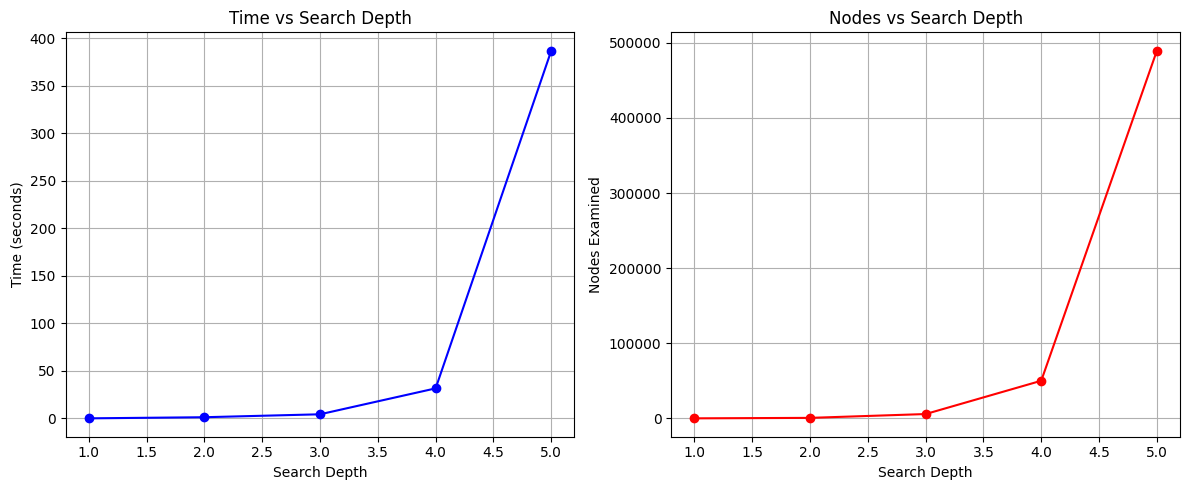

In [17]:
import gym
import gym_chess
import chess
import chess.svg
import numpy as np
import time
from typing import Tuple, Optional
from IPython.display import display, SVG, clear_output
import io
import os
import random
from PIL import Image
import imageio
from collections import defaultdict
import cairosvg


class ChessAlphaBetaAgent:
    def __init__(self, depth=3):
        self.depth = depth
        self.transposition_table = {}
        self.node_count = 0  # Track nodes examined
        self.time_taken = 0  # Track time taken

        # Piece-square tables (unchanged from original)
        self._pawn_table = np.array([
            [  0,   0,   0,   0,   0,   0,   0,   0],
            [ 50,  50,  50,  50,  50,  50,  50,  50],
            [ 10,  10,  20,  30,  30,  20,  10,  10],
            [  5,   5,  10,  25,  25,  10,   5,   5],
            [  0,   0,   0,  20,  20,   0,   0,   0],
            [  5,  -5, -10,   0,   0, -10,  -5,   5],
            [  5,  10,  10, -20, -20,  10,  10,   5],
            [  0,   0,   0,   0,   0,   0,   0,   0]
        ]).flatten()

        self._knight_table = np.array([
            [-50, -40, -30, -30, -30, -30, -40, -50],
            [-40, -20,   0,   5,   5,   0, -20, -40],
            [-30,   5,  10,  15,  15,  10,   5, -30],
            [-30,   0,  15,  20,  20,  15,   0, -30],
            [-30,   5,  15,  20,  20,  15,   5, -30],
            [-30,   0,  10,  15,  15,  10,   0, -30],
            [-40, -20,   0,   0,   0,   0, -20, -40],
            [-50, -40, -30, -30, -30, -30, -40, -50]
        ]).flatten()

        self._bishop_table = np.array([
            [-20, -10, -10, -10, -10, -10, -10, -20],
            [-10,   5,   0,   0,   0,   0,   5, -10],
            [-10,  10,  10,  10,  10,  10,  10, -10],
            [-10,   0,  10,  10,  10,  10,   0, -10],
            [-10,   5,   5,  10,  10,   5,   5, -10],
            [-10,   0,   5,  10,  10,   5,   0, -10],
            [-10,   0,   0,   0,   0,   0,   0, -10],
            [-20, -10, -10, -10, -10, -10, -10, -20]
        ]).flatten()

        self._rook_table = np.array([
            [  0,   0,   0,   0,   0,   0,   0,   0],
            [  5,  10,  10,  10,  10,  10,  10,   5],
            [ -5,   0,   0,   0,   0,   0,   0,  -5],
            [ -5,   0,   0,   0,   0,   0,   0,  -5],
            [ -5,   0,   0,   0,   0,   0,   0,  -5],
            [ -5,   0,   0,   0,   0,   0,   0,  -5],
            [ -5,   0,   0,   0,   0,   0,   0,  -5],
            [  0,   0,   0,   5,   5,   0,   0,   0]
        ]).flatten()

        self._queen_table = np.array([
            [-20, -10, -10,  -5,  -5, -10, -10, -20],
            [-10,   0,   0,   0,   0,   0,   0, -10],
            [-10,   0,   5,   5,   5,   5,   0, -10],
            [ -5,   0,   5,   5,   5,   5,   0,  -5],
            [  0,   0,   5,   5,   5,   5,   0,  -5],
            [-10,   5,   5,   5,   5,   5,   0, -10],
            [-10,   0,   5,   0,   0,   0,   0, -10],
            [-20, -10, -10,  -5,  -5, -10, -10, -20]
        ]).flatten()

        self._king_table = np.array([
            [-30, -40, -40, -50, -50, -40, -40, -30],
            [-30, -40, -40, -50, -50, -40, -40, -30],
            [-30, -40, -40, -50, -50, -40, -40, -30],
            [-30, -40, -40, -50, -50, -40, -40, -30],
            [-20, -30, -30, -40, -40, -30, -30, -20],
            [-10, -20, -20, -20, -20, -20, -20, -10],
            [ 20,  20,   0,   0,   0,   0,  20,  20],
            [ 20,  30,  10,   0,   0,  10,  30,  20]
        ]).flatten()
    def order_moves(self, board: chess.Board, moves: list) -> list:
        """Sophisticated move ordering with multiple heuristics"""
        move_scores = []

        for move in moves:
            score = 0

            # 1. Capture moves (MVV-LVA)
            if board.is_capture(move):
                victim = board.piece_at(move.to_square)
                attacker = board.piece_at(move.from_square)
                if victim and attacker:
                    piece_values = {
                        chess.PAWN: 1,
                        chess.KNIGHT: 3,
                        chess.BISHOP: 3,
                        chess.ROOK: 5,
                        chess.QUEEN: 9,
                        chess.KING: 0
                    }
                    score += 10 * piece_values[victim.piece_type] - piece_values[attacker.piece_type]

            # 2. Promotion
            if move.promotion:
                score += 900

            # 3. Checks
            if board.gives_check(move):
                score += 50

            # 4. Castling
            if board.is_castling(move):
                score += 30

            # 5. Killer moves and history heuristic could be added here

            move_scores.append((score, move))

        # Sort by score descending
        move_scores.sort(key=lambda x: x[0], reverse=True)
        return [move for (score, move) in move_scores]

    def evaluate_board(self, board: chess.Board) -> float:
        """Original evaluation function unchanged"""
        if board.is_checkmate():
            return -float('inf') if board.turn else float('inf')
        if board.is_game_over():
            return 0

        piece_values = {
            chess.PAWN: (100, self._pawn_table),
            chess.KNIGHT: (300, self._knight_table),
            chess.BISHOP: (300, self._bishop_table),
            chess.ROOK: (500, self._rook_table),
            chess.QUEEN: (900, self._queen_table),
            chess.KING: (0, self._king_table)
        }

        score = 0

        for square in chess.SQUARES:
            piece = board.piece_at(square)
            if piece:
                value, table = piece_values[piece.piece_type]
                multiplier = 1 if piece.color == chess.WHITE else -1
                score += value * multiplier
                table_value = table[square] if piece.color == chess.WHITE else table[chess.square_mirror(square)]
                score += table_value * 0.1

        mobility = len(list(board.legal_moves))
        score += mobility * 0.5 * (1 if board.turn == chess.WHITE else -1)
        score += self.evaluate_pawn_structure(board)
        score += self.evaluate_king_safety(board)

        return score
    def evaluate_board(self, board: chess.Board) -> float:
        """Enhanced evaluation function with more sophisticated features"""
        if board.is_checkmate():
            return -float('inf') if board.turn else float('inf')
        if board.is_game_over():
            return 0

        # Material and piece-square values
        piece_values = {
            chess.PAWN: (100, self._pawn_table),
            chess.KNIGHT: (300, self._knight_table),
            chess.BISHOP: (300, self._bishop_table),
            chess.ROOK: (500, self._rook_table),
            chess.QUEEN: (900, self._queen_table),
            chess.KING: (0, self._king_table)
        }

        score = 0

        # Material and positional evaluation
        for square in chess.SQUARES:
            piece = board.piece_at(square)
            if piece:
                value, table = piece_values[piece.piece_type]
                multiplier = 1 if piece.color == chess.WHITE else -1
                score += value * multiplier

                # Piece-square table
                table_value = table[square] if piece.color == chess.WHITE else table[chess.square_mirror(square)]
                score += table_value * 0.1

        # Mobility bonus
        mobility = len(list(board.legal_moves))
        score += mobility * 0.5 * (1 if board.turn == chess.WHITE else -1)

        # Pawn structure evaluation
        score += self.evaluate_pawn_structure(board)

        # King safety
        score += self.evaluate_king_safety(board)

        return score

    def evaluate_pawn_structure(self, board):
        """Evaluate pawn structure features"""
        pawn_score = 0
        white_pawns = board.pieces(chess.PAWN, chess.WHITE)
        black_pawns = board.pieces(chess.PAWN, chess.BLACK)

        # Doubled pawns penalty
        for file in range(8):
            white_count = sum(1 for pawn in white_pawns if chess.square_file(pawn) == file)
            black_count = sum(1 for pawn in black_pawns if chess.square_file(pawn) == file)
            pawn_score -= (white_count - 1) * 10 if white_count > 1 else 0
            pawn_score += (black_count - 1) * 10 if black_count > 1 else 0

        # Isolated pawns penalty
        for pawn in white_pawns:
            file = chess.square_file(pawn)
            if not any(p for p in white_pawns if abs(chess.square_file(p) - file) == 1):
                pawn_score -= 20

        for pawn in black_pawns:
            file = chess.square_file(pawn)
            if not any(p for p in black_pawns if abs(chess.square_file(p) - file) == 1):
                pawn_score += 20

        return pawn_score

    def evaluate_king_safety(self, board):
        """Evaluate king safety features"""
        safety_score = 0

        # King shelter
        white_king = board.king(chess.WHITE)
        black_king = board.king(chess.BLACK)

        if white_king:
            file = chess.square_file(white_king)
            safety_score -= min(file, 7 - file) * 5  # Penalize being on edge

        if black_king:
            file = chess.square_file(black_king)
            safety_score += min(file, 7 - file) * 5

        return safety_score

    # (Keep all other original methods unchanged until alpha_beta)
    def quiescence(self, board: chess.Board, alpha: float, beta: float, maximizing_player: bool) -> float:
        """Quiescence search to evaluate non-quiet positions"""
        stand_pat = self.evaluate_board(board)

        if maximizing_player:
            if stand_pat >= beta:
                return beta
            alpha = max(alpha, stand_pat)
        else:
            if stand_pat <= alpha:
                return alpha
            beta = min(beta, stand_pat)

        # Only consider captures
        for move in board.legal_moves:
            if not board.is_capture(move):
                continue

            board.push(move)
            score = self.quiescence(board, alpha, beta, not maximizing_player)
            board.pop()

            if maximizing_player:
                if score >= beta:
                    return beta
                alpha = max(alpha, score)
            else:
                if score <= alpha:
                    return alpha
                beta = min(beta, score)

        return alpha if maximizing_player else beta

    def alpha_beta(self, board: chess.Board, depth: int, alpha: float, beta: float, maximizing_player: bool) -> Tuple[float, Optional[chess.Move]]:
        self.node_count += 1  # Count each node visit

        # Original alpha-beta implementation
        if board.is_checkmate():
            return (-float('inf') if maximizing_player else float('inf')), None
        if board.is_game_over():
            return 0, None

        if depth == 0:
            return self.quiescence(board, alpha, beta, maximizing_player), None

        board_fen = board.fen()
        tt_entry = self.transposition_table.get(board_fen)
        if tt_entry and tt_entry['depth'] >= depth:
            if tt_entry['flag'] == 'EXACT':
                return tt_entry['score'], tt_entry['move']
            elif tt_entry['flag'] == 'LOWERBOUND':
                alpha = max(alpha, tt_entry['score'])
            elif tt_entry['flag'] == 'UPPERBOUND':
                beta = min(beta, tt_entry['score'])
            if alpha >= beta:
                return tt_entry['score'], tt_entry['move']

        legal_moves = list(board.legal_moves)
        if not legal_moves:
            return self.evaluate_board(board), None

        legal_moves = self.order_moves(board, legal_moves)
        best_move = legal_moves[0]
        best_score = -float('inf') if maximizing_player else float('inf')

        for move in legal_moves:
            board.push(move)
            score, _ = self.alpha_beta(board, depth-1, alpha, beta, not maximizing_player)
            board.pop()

            if maximizing_player:
                if score > best_score:
                    best_score = score
                    best_move = move
                alpha = max(alpha, best_score)
            else:
                if score < best_score:
                    best_score = score
                    best_move = move
                beta = min(beta, best_score)

            if beta <= alpha:
                break

        flag = 'EXACT'
        if best_score <= alpha:
            flag = 'UPPERBOUND'
        elif best_score >= beta:
            flag = 'LOWERBOUND'

        self.transposition_table[board_fen] = {
            'score': best_score,
            'move': best_move,
            'depth': depth,
            'flag': flag
        }

        return best_score, best_move

    def get_best_move(self, board: chess.Board) -> chess.Move:
        """Modified to track performance metrics"""
        self.node_count = 0  # Reset counter
        start_time = time.time()

        best_move = None
        for current_depth in range(1, self.depth + 1):
            _, best_move = self.alpha_beta(board, current_depth, -float('inf'), float('inf'), board.turn == chess.WHITE)

        self.time_taken = time.time() - start_time
        return best_move or random.choice(list(board.legal_moves))

def run_depth_experiment(max_depth=5, num_positions=3):
    """Run experiments with varying depths and collect metrics"""
    test_positions = [
        "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",  # Start position
        "r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNBQKB1R w KQkq - 0 3",  # Common opening
        "r1bqkbnr/pp1p1ppp/2n1p3/2p5/4P3/5N2/PPPP1PPP/RNBQKB1R w KQkq - 0 4"  # Another position
    ]

    results = []

    for depth in range(1, max_depth + 1):
        print(f"Testing depth {depth}...")
        total_nodes = 0
        total_time = 0

        agent = ChessAlphaBetaAgent(depth=depth)

        for fen in test_positions:
            board = chess.Board(fen)
            agent.get_best_move(board)  # This updates node_count and time_taken
            total_nodes += agent.node_count
            total_time += agent.time_taken

        nodes = total_nodes
        time = total_time

        results.append({
            'Depth': depth,
            'Time (s)': time,
            'Nodes': nodes
        })

    return pd.DataFrame(results)

def plot_performance(results_df):
    """Plot time and nodes vs depth"""
    plt.figure(figsize=(12, 5))

    # Time plot
    plt.subplot(1, 2, 1)
    plt.plot(results_df['Depth'], results_df['Time (s)'], 'bo-')
    plt.xlabel('Search Depth')
    plt.ylabel('Time (seconds)')
    plt.title('Time vs Search Depth')
    plt.grid(True)

    # Nodes plot
    plt.subplot(1, 2, 2)
    plt.plot(results_df['Depth'], results_df['Nodes'], 'ro-')
    plt.xlabel('Search Depth')
    plt.ylabel('Nodes Examined')
    plt.title('Nodes vs Search Depth')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def display_board(board, last_move=None):
    """Display the chess board using SVG"""
    svg = chess.svg.board(
        board=board,
        lastmove=last_move,
        size=400
    )
    display(SVG(svg))
    return svg

def play_chess_game(depth=3):
    """Original game play function"""
    board = chess.Board()
    agent = ChessAlphaBetaAgent(depth=depth)
    last_move = None

    while not board.is_game_over():
        clear_output(wait=True)
        print(f"Move {len(board.move_stack) + 1}: {'White' if board.turn == chess.WHITE else 'Black'} to move")
        display_board(board, last_move)

        if not any(board.legal_moves):
            print("No legal moves available")
            break

        move = agent.get_best_move(board)

        if move is None or move not in board.legal_moves:
            print("Warning: Invalid move selected, choosing random legal move")
            move = random.choice(list(board.legal_moves))

        print(f"Playing: {move.uci()}")
        board.push(move)
        last_move = move
        time.sleep(0.5)

    clear_output(wait=True)
    print("Final board after", len(board.move_stack), "moves:")
    display_board(board, last_move)

    if board.is_checkmate():
        winner = "White" if board.turn == chess.BLACK else "Black"
        print(f"{winner} wins by checkmate!")
    elif board.is_stalemate():
        print("Game ended in stalemate")
    else:
        print("Game ended:", board.result())

# Run the experiment and show plots
print("Running depth performance experiment...")
results = run_depth_experiment(max_depth=5)
print("\nPerformance Results:")
print(results)

plot_performance(results)



Saving game video...
Game saved as chess_game.mp4
Final board after 171 moves:


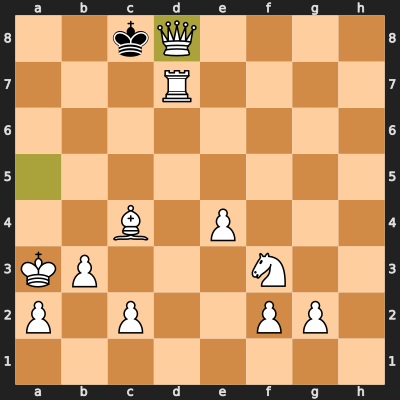

White wins by checkmate!


In [18]:

def save_game_video(board, moves, filename="chess_game.mp4", fps=2):
    """Save a chess game as a video file"""
    frames = []

    # Create temporary board to replay the game
    temp_board = chess.Board()

    # Add initial position
    svg = chess.svg.board(board=temp_board, size=400)
    png_data = cairosvg.svg2png(bytestring=svg)
    img = Image.open(io.BytesIO(png_data))
    frames.append(img)

    # Add each move
    for move in moves:
        temp_board.push(move)
        svg = chess.svg.board(board=temp_board, lastmove=move, size=400)
        png_data = cairosvg.svg2png(bytestring=svg)
        img = Image.open(io.BytesIO(png_data))
        frames.append(img)

    # Add extra frames for final position
    for _ in range(10):
        frames.append(img)

    # Save as video
    with imageio.get_writer(filename, fps=fps) as writer:
        for frame in frames:
            writer.append_data(np.array(frame))

def play_and_save_chess_game(depth=3, video_filename="chess_game.mp4"):
    """Play a game and save it as video"""
    board = chess.Board()
    agent = ChessAlphaBetaAgent(depth=depth)
    moves = []

    while not board.is_game_over():
        clear_output(wait=True)
        print(f"Move {len(board.move_stack) + 1}: {'White' if board.turn == chess.WHITE else 'Black'} to move")
        display_board(board, moves[-1] if moves else None)

        if not any(board.legal_moves):
            print("No legal moves available")
            break

        move = agent.get_best_move(board)

        if move is None or move not in board.legal_moves:
            print("Warning: Invalid move selected, choosing random legal move")
            move = random.choice(list(board.legal_moves))

        print(f"Playing: {move.uci()}")
        board.push(move)
        moves.append(move)
        time.sleep(0.5)

    # Game over - save video
    clear_output(wait=True)
    print("Saving game video...")
    save_game_video(board, moves, video_filename)
    print(f"Game saved as {video_filename}")

    # Show final position
    print("Final board after", len(board.move_stack), "moves:")
    display_board(board, moves[-1] if moves else None)

    if board.is_checkmate():
        winner = "White" if board.turn == chess.BLACK else "Black"
        print(f"{winner} wins by checkmate!")
    elif board.is_stalemate():
        print("Game ended in stalemate")
    else:
        print("Game ended:", board.result())

def display_board(board, last_move=None):
    """Display the chess board using SVG"""
    svg = chess.svg.board(
        board=board,
        lastmove=last_move,
        size=400
    )
    display(SVG(svg))
    return svg

# Start a game and save as video
play_and_save_chess_game(depth=2, video_filename="chess_game.mp4")